# importing the dataset

In [1]:
import pandas as pd
df = pd.read_json('unhpl.json')
df.head()

,businessDate,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice
0,2026-08-10,46,4858,1821167.5,379.5,373.1,374.0
1,2026-08-07,53,7991,3008338.7,381.5,375.0,375.0
2,2026-08-06,90,23316,8867818.6,385.0,375.5,379.0
3,2026-08-05,56,9947,3769629.9,388.0,377.1,379.9
4,2026-08-04,88,21045,7997141.9,388.0,378.2,383.9


# data preprocessing

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   businessDate         224 non-null    object 
 1   totalTrades          224 non-null    int64  
 2   totalTradedQuantity  224 non-null    int64  
 3   totalTradedValue     224 non-null    float64
 4   highPrice            224 non-null    float64
 5   lowPrice             224 non-null    float64
 6   closePrice           224 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 12.4+ KB


In [3]:
df.describe()

,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice
count,224.000000,2.240000e+02,2.240000e+02,224.000000,224.000000,224.000000
mean,490.781250,1.842857e+05,9.029447e+07,473.010670,454.797277,463.154509
std,474.738164,2.013728e+05,1.014613e+08,53.117306,49.330645,50.846291
min,33.000000,4.858000e+03,1.821168e+06,379.500000,370.000000,374.000000
25%,148.250000,3.441475e+04,1.499409e+07,415.750000,404.600000,408.837500
50%,346.500000,1.031230e+05,4.883076e+07,485.550000,468.000000,475.000000
75%,646.000000,2.568460e+05,1.321853e+08,516.025000,494.000000,502.300000
max,2710.000000,1.146555e+06,5.877639e+08,571.000000,549.000000,560.000000


In [4]:
df.isnull().sum()

businessDate           0
totalTrades            0
totalTradedQuantity    0
totalTradedValue       0
highPrice              0
lowPrice               0
closePrice             0
dtype: int64

# Since the businessDate is obj , i changed it to datetime

In [5]:
df['businessDate'] = pd.to_datetime(df['businessDate'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   businessDate         224 non-null    datetime64[ns]
 1   totalTrades          224 non-null    int64         
 2   totalTradedQuantity  224 non-null    int64         
 3   totalTradedValue     224 non-null    float64       
 4   highPrice            224 non-null    float64       
 5   lowPrice             224 non-null    float64       
 6   closePrice           224 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 12.4 KB


In [7]:
df['year'] = df['businessDate'].dt.year
df['month'] = df['businessDate'].dt.month
df = df.sort_values('businessDate')

In [8]:
df

,businessDate,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice,year,month
223,2025-08-11,343,95193,37038550.7,397.9,383.0,383.82,2025,8
222,2025-08-12,274,81542,31015101.2,385.0,377.0,380.33,2025,8
221,2025-08-13,324,117397,44894624.4,392.0,375.9,380.87,2025,8
220,2025-08-14,346,85067,32872938.3,394.7,379.1,390.47,2025,8
219,2025-08-17,222,50520,19532195.4,394.0,384.0,384.88,2025,8
...,...,...,...,...,...,...,...,...,...
4,2026-08-04,88,21045,7997141.9,388.0,378.2,383.90,2026,8
3,2026-08-05,56,9947,3769629.9,388.0,377.1,379.90,2026,8
2,2026-08-06,90,23316,8867818.6,385.0,375.5,379.00,2026,8
1,2026-08-07,53,7991,3008338.7,381.5,375.0,375.00,2026,8


# checking how to import rsi and playing with it , if for future use

In [9]:
import pandas_ta as ta

In [10]:
df['rsi']  = ta.rsi(df['closePrice'],length=14)
df

,businessDate,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice,year,month,rsi
223,2025-08-11,343,95193,37038550.7,397.9,383.0,383.82,2025,8,NaN
222,2025-08-12,274,81542,31015101.2,385.0,377.0,380.33,2025,8,0.000000
221,2025-08-13,324,117397,44894624.4,392.0,375.9,380.87,2025,8,1.176214
220,2025-08-14,346,85067,32872938.3,394.7,379.1,390.47,2025,8,19.340016
219,2025-08-17,222,50520,19532195.4,394.0,384.0,384.88,2025,8,17.341296
...,...,...,...,...,...,...,...,...,...,...
4,2026-08-04,88,21045,7997141.9,388.0,378.2,383.90,2026,8,39.844465
3,2026-08-05,56,9947,3769629.9,388.0,377.1,379.90,2026,8,36.824087
2,2026-08-06,90,23316,8867818.6,385.0,375.5,379.00,2026,8,36.159904
1,2026-08-07,53,7991,3008338.7,381.5,375.0,375.00,2026,8,33.286321


In [11]:
df.value_counts

<bound method DataFrame.value_counts of     businessDate  totalTrades  totalTradedQuantity  totalTradedValue  \
223   2025-08-11          343                95193        37038550.7   
222   2025-08-12          274                81542        31015101.2   
221   2025-08-13          324               117397        44894624.4   
220   2025-08-14          346                85067        32872938.3   
219   2025-08-17          222                50520        19532195.4   
..           ...          ...                  ...               ...   
4     2026-08-04           88                21045         7997141.9   
3     2026-08-05           56                 9947         3769629.9   
2     2026-08-06           90                23316         8867818.6   
1     2026-08-07           53                 7991         3008338.7   
0     2026-08-10           46                 4858         1821167.5   

     highPrice  lowPrice  closePrice  year  month        rsi  
223      397.9     383.0      38

In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
df["rsi"].isna().sum()

np.int64(1)

In [14]:
df[["businessDate", "closePrice", "rsi"]].tail()

,businessDate,closePrice,rsi
4,2026-08-04,383.9,39.844465
3,2026-08-05,379.9,36.824087
2,2026-08-06,379.0,36.159904
1,2026-08-07,375.0,33.286321
0,2026-08-10,374.0,32.589064


In [15]:
df = df.sort_values("businessDate").reset_index(drop=True)

In [16]:
df

,businessDate,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice,year,month,rsi
0,2025-08-11,343,95193,37038550.7,397.9,383.0,383.82,2025,8,NaN
1,2025-08-12,274,81542,31015101.2,385.0,377.0,380.33,2025,8,0.000000
2,2025-08-13,324,117397,44894624.4,392.0,375.9,380.87,2025,8,1.176214
3,2025-08-14,346,85067,32872938.3,394.7,379.1,390.47,2025,8,19.340016
4,2025-08-17,222,50520,19532195.4,394.0,384.0,384.88,2025,8,17.341296
...,...,...,...,...,...,...,...,...,...,...
219,2026-08-04,88,21045,7997141.9,388.0,378.2,383.90,2026,8,39.844465
220,2026-08-05,56,9947,3769629.9,388.0,377.1,379.90,2026,8,36.824087
221,2026-08-06,90,23316,8867818.6,385.0,375.5,379.00,2026,8,36.159904
222,2026-08-07,53,7991,3008338.7,381.5,375.0,375.00,2026,8,33.286321


# changing businessDate into index for the dataset

In [17]:
df =  df.set_index('businessDate')
df

,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice,year,month,rsi
businessDate,,,,,,,,,
2025-08-11,343,95193,37038550.7,397.9,383.0,383.82,2025,8,NaN
2025-08-12,274,81542,31015101.2,385.0,377.0,380.33,2025,8,0.000000
2025-08-13,324,117397,44894624.4,392.0,375.9,380.87,2025,8,1.176214
2025-08-14,346,85067,32872938.3,394.7,379.1,390.47,2025,8,19.340016
2025-08-17,222,50520,19532195.4,394.0,384.0,384.88,2025,8,17.341296
...,...,...,...,...,...,...,...,...,...
2026-08-04,88,21045,7997141.9,388.0,378.2,383.90,2026,8,39.844465
2026-08-05,56,9947,3769629.9,388.0,377.1,379.90,2026,8,36.824087
2026-08-06,90,23316,8867818.6,385.0,375.5,379.00,2026,8,36.159904


In [18]:
df.index

DatetimeIndex(['2025-08-11', '2025-08-12', '2025-08-13', '2025-08-14',
               '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
               '2025-08-21', '2025-08-24',
               ...
               '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31',
               '2026-08-03', '2026-08-04', '2026-08-05', '2026-08-06',
               '2026-08-07', '2026-08-10'],
              dtype='datetime64[ns]', name='businessDate', length=224, freq=None)

<Axes: xlabel='businessDate'>

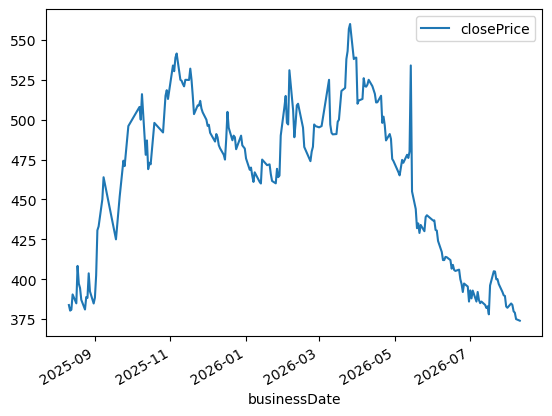

In [19]:
df.plot.line(y = 'closePrice', use_index = True)

In [20]:
df

,totalTrades,totalTradedQuantity,totalTradedValue,highPrice,lowPrice,closePrice,year,month,rsi
businessDate,,,,,,,,,
2025-08-11,343,95193,37038550.7,397.9,383.0,383.82,2025,8,NaN
2025-08-12,274,81542,31015101.2,385.0,377.0,380.33,2025,8,0.000000
2025-08-13,324,117397,44894624.4,392.0,375.9,380.87,2025,8,1.176214
2025-08-14,346,85067,32872938.3,394.7,379.1,390.47,2025,8,19.340016
2025-08-17,222,50520,19532195.4,394.0,384.0,384.88,2025,8,17.341296
...,...,...,...,...,...,...,...,...,...
2026-08-04,88,21045,7997141.9,388.0,378.2,383.90,2026,8,39.844465
2026-08-05,56,9947,3769629.9,388.0,377.1,379.90,2026,8,36.824087
2026-08-06,90,23316,8867818.6,385.0,375.5,379.00,2026,8,36.159904


# I started splitting the dataset into another df as main_df where only my feature columns are added

In [21]:
list = ['highPrice', 'lowPrice','closePrice','totalTradedValue']
main_df = df[list]

In [22]:
main_df

,highPrice,lowPrice,closePrice,totalTradedValue
businessDate,,,,
2025-08-11,397.9,383.0,383.82,37038550.7
2025-08-12,385.0,377.0,380.33,31015101.2
2025-08-13,392.0,375.9,380.87,44894624.4
2025-08-14,394.7,379.1,390.47,32872938.3
2025-08-17,394.0,384.0,384.88,19532195.4
...,...,...,...,...
2026-08-04,388.0,378.2,383.90,7997141.9
2026-08-05,388.0,377.1,379.90,3769629.9
2026-08-06,385.0,375.5,379.00,8867818.6


# making my target for prediction

In [23]:
main_df['tomorrow'] = main_df['closePrice'].shift(-1)
main_df

,highPrice,lowPrice,closePrice,totalTradedValue,tomorrow
businessDate,,,,,
2025-08-11,397.9,383.0,383.82,37038550.7,380.33
2025-08-12,385.0,377.0,380.33,31015101.2,380.87
2025-08-13,392.0,375.9,380.87,44894624.4,390.47
2025-08-14,394.7,379.1,390.47,32872938.3,384.88
2025-08-17,394.0,384.0,384.88,19532195.4,408.35
...,...,...,...,...,...
2026-08-04,388.0,378.2,383.90,7997141.9,379.90
2026-08-05,388.0,377.1,379.90,3769629.9,379.00
2026-08-06,385.0,375.5,379.00,8867818.6,375.00


In [24]:
main_df['target'] = (main_df['tomorrow'] > main_df['closePrice']).astype(int)
main_df

,highPrice,lowPrice,closePrice,totalTradedValue,tomorrow,target
businessDate,,,,,,
2025-08-11,397.9,383.0,383.82,37038550.7,380.33,0
2025-08-12,385.0,377.0,380.33,31015101.2,380.87,1
2025-08-13,392.0,375.9,380.87,44894624.4,390.47,1
2025-08-14,394.7,379.1,390.47,32872938.3,384.88,0
2025-08-17,394.0,384.0,384.88,19532195.4,408.35,1
...,...,...,...,...,...,...
2026-08-04,388.0,378.2,383.90,7997141.9,379.90,0
2026-08-05,388.0,377.1,379.90,3769629.9,379.00,0
2026-08-06,385.0,375.5,379.00,8867818.6,375.00,0


# Making model (Using RandomForestClassifier)

In [25]:
from sklearn.ensemble import RandomForestClassifier

model  = RandomForestClassifier(n_estimators= 100, random_state = 42, min_samples_split=100)

train = main_df.iloc[:179]
test = main_df.iloc[179:]


In [26]:
model.fit(train[list], train['target'])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

preds = model.predict(test[list])
accuracy = accuracy_score(test['target'], preds)
precision = precision_score(test['target'], preds)
print(accuracy , precision)

0.5333333333333333 0.23529411764705882


In [28]:
preds = pd.Series(preds, index = test.index)
combined = pd.concat([test['target'] , preds], axis = 1)
combined.head(8)

,target,0
businessDate,,
2026-06-09,0,0
2026-06-10,1,0
2026-06-11,0,0
2026-06-12,0,0
2026-06-15,0,0
2026-06-16,1,0
2026-06-17,0,0
2026-06-18,0,0


<Axes: xlabel='businessDate'>

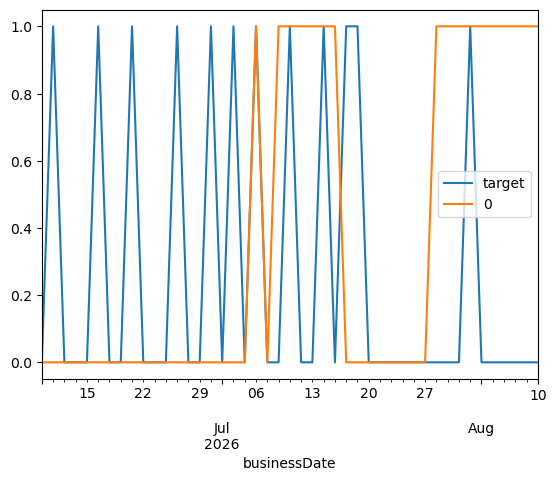

In [29]:
combined.plot()

In [38]:
main_df.columns

Index(['highPrice', 'lowPrice', 'closePrice', 'totalTradedValue', 'tomorrow',
       'target'],
      dtype='object')

# seeing feature importance

In [45]:
feature_importance = pd.DataFrame({
    "Feature": main_df[list].columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,highPrice,0.431256
1,lowPrice,0.193184
3,totalTradedValue,0.188503
2,closePrice,0.187058


In [46]:
main_df['rsi'] = df['rsi']

In [47]:
main_df

,highPrice,lowPrice,closePrice,totalTradedValue,tomorrow,target,rsi
businessDate,,,,,,,
2025-08-11,397.9,383.0,383.82,37038550.7,380.33,0,NaN
2025-08-12,385.0,377.0,380.33,31015101.2,380.87,1,0.000000
2025-08-13,392.0,375.9,380.87,44894624.4,390.47,1,1.176214
2025-08-14,394.7,379.1,390.47,32872938.3,384.88,0,19.340016
2025-08-17,394.0,384.0,384.88,19532195.4,408.35,1,17.341296
...,...,...,...,...,...,...,...
2026-08-04,388.0,378.2,383.90,7997141.9,379.90,0,39.844465
2026-08-05,388.0,377.1,379.90,3769629.9,379.00,0,36.824087
2026-08-06,385.0,375.5,379.00,8867818.6,375.00,0,36.159904


<Axes: xlabel='businessDate'>

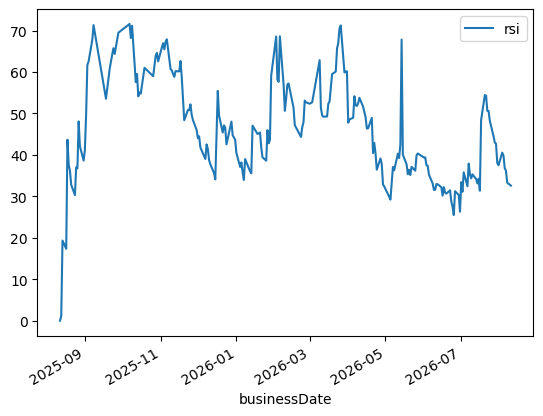

In [48]:
main_df.plot.line(y = 'rsi', use_index = True)